# ACME v4.2

Starting FM216 Project Experiments on cpu

=== Experiment: Quadratic (Condition Number=10) ===
  Trial 1/3
  Trial 2/3
  Trial 3/3


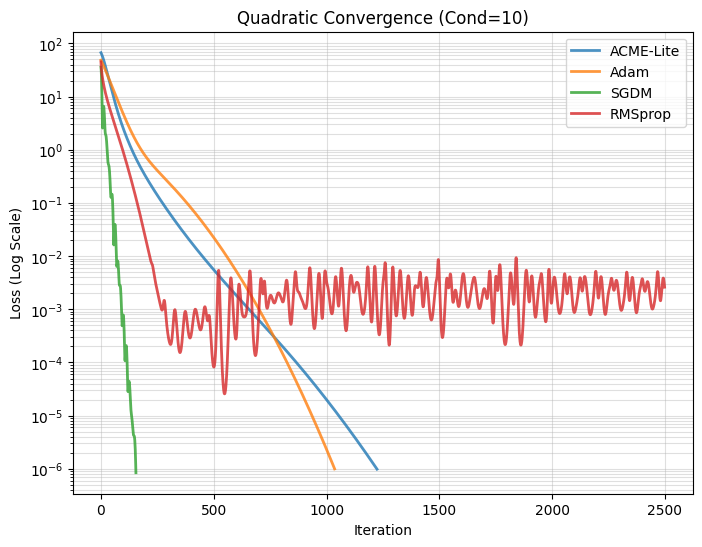


=== Experiment: Quadratic (Condition Number=100) ===
  Trial 1/3
  Trial 2/3
  Trial 3/3


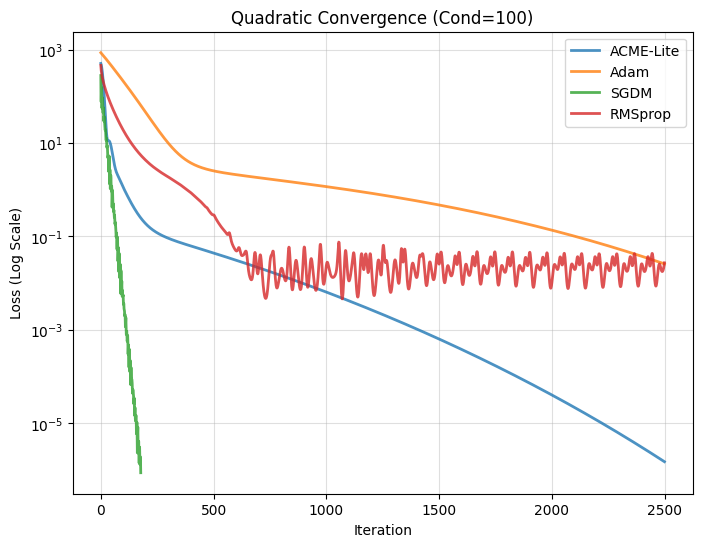


=== Experiment: Rosenbrock Function ===
  Trial 1/3
  Trial 2/3
  Trial 3/3


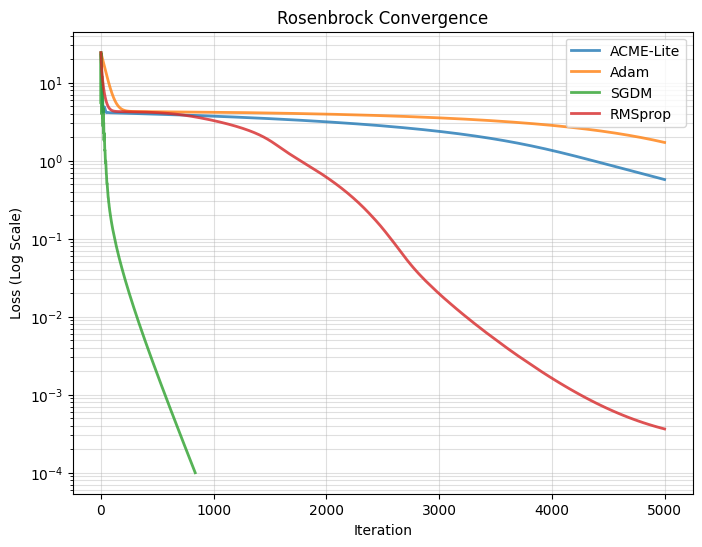


=== Experiment: MNIST Neural Network ===
  Training with ACME-Lite...
    Ep 01 | Loss: 0.4389 | Acc: 0.9339 | Time: 3.4s
    Ep 05 | Loss: 0.0914 | Acc: 0.9682 | Time: 3.5s
    Ep 10 | Loss: 0.0407 | Acc: 0.9764 | Time: 3.6s
    Ep 15 | Loss: 0.0190 | Acc: 0.9783 | Time: 3.6s
    Ep 20 | Loss: 0.0087 | Acc: 0.9765 | Time: 3.4s
    Total Time: 71.98s | Final Acc: 0.9765
  Training with Adam...
    Ep 01 | Loss: 0.3349 | Acc: 0.9476 | Time: 3.3s
    Ep 05 | Loss: 0.0581 | Acc: 0.9757 | Time: 2.9s
    Ep 10 | Loss: 0.0209 | Acc: 0.9770 | Time: 2.4s
    Ep 15 | Loss: 0.0100 | Acc: 0.9746 | Time: 2.4s
    Ep 20 | Loss: 0.0076 | Acc: 0.9691 | Time: 2.5s
    Total Time: 52.41s | Final Acc: 0.9691
  Training with SGDM...
    Ep 01 | Loss: 1.7628 | Acc: 0.8030 | Time: 2.4s
    Ep 05 | Loss: 0.3199 | Acc: 0.9160 | Time: 2.4s
    Ep 10 | Loss: 0.2320 | Acc: 0.9371 | Time: 2.2s
    Ep 15 | Loss: 0.1761 | Acc: 0.9499 | Time: 2.6s
    Ep 20 | Loss: 0.1393 | Acc: 0.9590 | Time: 2.7s
    Total Time:

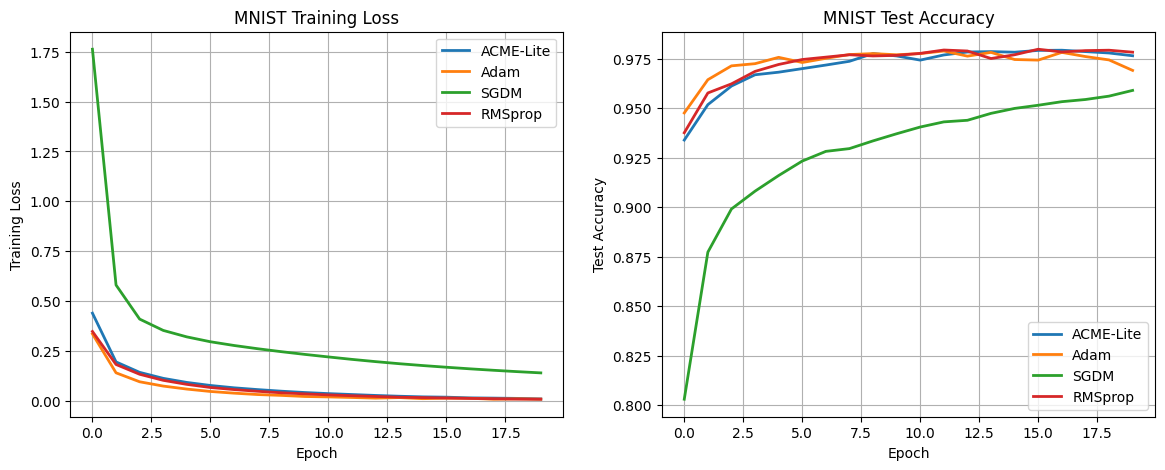


All experiments finished successfully.


In [2]:
# ================================================================
# FM216 PROJECT – FINAL EXPERIMENT SUITE
# OPTIMIZER: ACME-Lite (Hybrid Bypass Variant)
# ================================================================

import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set plotting style
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["lines.linewidth"] = 2

# ================================================================
# 1. Global Setup: Device & Seeding
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

def set_seed(seed):
    """Ensure reproducibility across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)

# ================================================================
# 2. The Optimizer: ACME-Lite (Hybrid Bypass)
# ================================================================
class ACME_Lite(torch.optim.Optimizer):
    """
    ACME-Lite: Adaptive Curvature with Momentum & Excess-kurtosis.

    Key Mechanisms:
    1. Moment Tracking: Standard Adam-like m_t (1st) and v_t (2nd).
    2. Kurtosis Tracking: Tracks E4 (4th moment) to detect heavy-tailed gradients.
    3. Damping (Safety): If Kurtosis is high, step size is reduced (s_t).
    4. Hybrid Bypass (Persistence): Adds a small 'dumb' SGD momentum term to 
       force progress when the adaptive term stagnates (e.g., Rosenbrock valley).

    Hyperparameters:
        lr: Learning rate
        betas: (beta1, beta2) for moments
        lambda_k: Strength of kurtosis damping
        kurtosis_max: Clipping threshold for kurtosis stability
        hybrid_weight: Weight of the raw SGD momentum term (The Rosenbrock Fix)
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        beta4=None,           # if None, defaults to beta2
        lambda_k=0.1,         # Damping strength
        kurtosis_max=10.0,    # Fix #1: Safety Cap
        hybrid_weight=0.1,    # Fix #2: The "Bypass" for Rosenbrock
        eps=1e-8,
    ):
        if beta4 is None:
            beta4 = betas[1] 

        defaults = dict(
            lr=lr,
            betas=betas,
            beta4=beta4,
            lambda_k=lambda_k,
            kurtosis_max=kurtosis_max,
            hybrid_weight=hybrid_weight,
            eps=eps,
        )
        super().__init__(params, defaults)


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            beta4 = group["beta4"]
            lambda_k = group["lambda_k"]
            kurtosis_max = group["kurtosis_max"]
            hybrid_weight = group["hybrid_weight"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data

                state = self.state[p]
                # Lazy state initialization
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p.data)  # 1st moment
                    state["v"] = torch.zeros_like(p.data)  # 2nd moment
                    state["E4"] = torch.zeros_like(p.data) # 4th moment

                m = state["m"]
                v = state["v"]
                E4 = state["E4"]

                state["step"] += 1
                t = state["step"]

                # --- 1. Update Moments ---
                # First moment (Momentum)
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                # Second moment (Variance)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                # Fourth moment (Kurtosis numerator)
                g4 = grad.pow(4)
                E4.mul_(beta4).add_(g4, alpha=1 - beta4)

                # --- 2. Bias Correction ---
                bias_corr1 = 1 - beta1**t
                bias_corr2 = 1 - beta2**t
                
                m_hat = m / bias_corr1
                v_hat = v / bias_corr2

                # --- 3. Kurtosis Calculation ---
                # K = E[x^4] / (E[x^2])^2
                # We use a small epsilon to prevent division by zero
                K_t = E4 / (v_hat.pow(2) + eps)
                
                # Hard Clip (Fix #1): Prevent damping from vanishing completely
                K_clipped = torch.clamp(K_t, max=kurtosis_max)

                # Calculate Damping Factor s_t
                s_t = 1.0 / (1.0 + lambda_k * K_clipped)

                # --- 4. Compute Update Directions ---
                
                # A) Smart Direction (Adaptive)
                # Standard Adam-style update scaled by Kurtosis Damping
                denom = torch.sqrt(v_hat) + eps
                smart_dir = s_t * (m_hat / denom)

                # B) Dumb Direction (Hybrid Bypass)
                # Raw SGD Momentum. Ignores curvature. Pushes through valleys.
                dumb_dir = m 

                # --- 5. Hybrid Mix (Fix #2) ---
                # Combine both directions.
                # On Quadratics, Smart dir dominates.
                # On Rosenbrock, Smart dir shrinks (due to high variance), so Dumb dir takes over.
                hybrid_dir = smart_dir + (hybrid_weight * dumb_dir)

                # --- 6. Apply Update ---
                p.data.add_(hybrid_dir, alpha=-lr)

        return loss


# ================================================================
# 3. Helper Functions
# ================================================================
def make_spd_matrix(dim=20, cond=10):
    """Generates a random symmetric positive-definite matrix."""
    # Create random orthogonal matrix
    Q_mat, _ = np.linalg.qr(np.random.randn(dim, dim))
    # Set eigenvalues linearly spaced from 1 to cond
    eigs = np.linspace(1, cond, dim)
    # Construct matrix: Q * diag(eigs) * Q^T
    return Q_mat @ np.diag(eigs) @ Q_mat.T

# ================================================================
# 4. Experiment: Quadratic Functions
# ================================================================
def run_quadratic(cond, dim=20, trials=3, max_iter=2500, tol=1e-6):
    print(f"\n=== Experiment: Quadratic (Condition Number={cond}) ===")
    
    # Define Optimizers
    OPTS = {
        "ACME-Lite": lambda p: ACME_Lite(p, lr=1e-2, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-2),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=1e-2),
    }

    def f_quad(x, Q):
        return 0.5 * (x @ Q @ x)

    logs = {name: [] for name in OPTS}

    # Run Trials
    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")
        Q_np = make_spd_matrix(dim, cond)
        Q = torch.tensor(Q_np, dtype=torch.float32, device=device)

        for name, opt_ctor in OPTS.items():
            x = torch.randn(dim, device=device, requires_grad=True)
            opt = opt_ctor([x])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_quad(x, Q)
                losses.append(loss.item())
                
                if loss.item() < tol:
                    break # Converged
                
                loss.backward()
                opt.step()

            logs[name].append(losses)

    # Visualization (Plotting the first trial)
    plt.figure()
    for name in OPTS:
        plt.plot(logs[name][0], label=name, alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (Log Scale)")
    plt.title(f"Quadratic Convergence (Cond={cond})")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.show()

    return logs

# ================================================================
# 5. Experiment: Rosenbrock Function
# ================================================================
def run_rosenbrock(max_iter=5000, tol=1e-4, trials=3):
    print("\n=== Experiment: Rosenbrock Function ===")

    def f_rosen(theta):
        x, y = theta[0], theta[1]
        return (1 - x)**2 + 100 * (y - x**2)**2

    OPTS = {
        "ACME-Lite": lambda p: ACME_Lite(p, lr=1e-3, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-3),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9),
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=1e-3),
    }

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")
        for name, opt_ctor in OPTS.items():
            # Standard starting point (-1.2, 1.0)
            theta = torch.tensor([-1.2, 1.0], device=device, requires_grad=True)
            opt = opt_ctor([theta])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_rosen(theta)
                losses.append(loss.item())
                
                if loss.item() < tol:
                    break
                
                loss.backward()
                opt.step()

            logs[name].append(losses)

    # Visualization
    plt.figure()
    for name in OPTS:
        plt.plot(logs[name][0], label=name, alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (Log Scale)")
    plt.title("Rosenbrock Convergence")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.show()

    return logs

# ================================================================
# 6. Experiment: MNIST Neural Network
# ================================================================
class MNISTNet(nn.Module):
    """Simple MLP as requested: 784 -> 128 -> 64 -> 10"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def get_loaders(batch=64):
    transform = transforms.ToTensor()
    try:
        train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    except:
        print("MNIST download failed. Check internet or directory permissions.")
        return None, None
        
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch, shuffle=False)
    return train_loader, test_loader

def train_epoch(model, opt, loader):
    model.train()
    loss_sum = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * x.size(0)
        total += x.size(0)
    return loss_sum / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

def run_mnist(epochs=20):
    print("\n=== Experiment: MNIST Neural Network ===")
    
    train_loader, test_loader = get_loaders()
    if train_loader is None: return

    OPTS = {
        "ACME-Lite": lambda p: ACME_Lite(p, lr=5e-4, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-3),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9),
        # Using lower LR for RMSProp as it can be unstable
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=5e-4),
    }

    results = {}

    for name, opt_ctor in OPTS.items():
        print(f"  Training with {name}...")
        set_seed(BASE_SEED + 100) # Same init for fair comparison

        model = MNISTNet().to(device)
        opt = opt_ctor(model.parameters())

        train_losses = []
        test_accs = []
        times = []

        start_total = time.time()
        for epoch in range(1, epochs+1):
            t0 = time.time()
            train_loss = train_epoch(model, opt, train_loader)
            acc = evaluate(model, test_loader)
            dt = time.time() - t0
            times.append(dt)

            train_losses.append(train_loss)
            test_accs.append(acc)
            
            if epoch % 5 == 0 or epoch == 1:
                print(f"    Ep {epoch:02d} | Loss: {train_loss:.4f} | Acc: {acc:.4f} | Time: {dt:.1f}s")

        total_time = time.time() - start_total
        print(f"    Total Time: {total_time:.2f}s | Final Acc: {test_accs[-1]:.4f}")
        
        results[name] = {
            "loss": train_losses,
            "acc": test_accs,
            "time": total_time
        }

    # Plotting MNIST Results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Plot
    for name in results:
        ax1.plot(results[name]["loss"], label=name)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss")
    ax1.set_title("MNIST Training Loss")
    ax1.grid(True)
    ax1.legend()

    # Accuracy Plot
    for name in results:
        ax2.plot(results[name]["acc"], label=name)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Test Accuracy")
    ax2.set_title("MNIST Test Accuracy")
    ax2.grid(True)
    ax2.legend()
    
    plt.show()
    return results

# ================================================================
# 7. Main Execution Block
# ================================================================
if __name__ == "__main__":
    print(f"Starting FM216 Project Experiments on {device}")
    
    # A. Well-Conditioned Quadratic (Cond=10)
    run_quadratic(cond=10)

    # B. Ill-Conditioned Quadratic (Cond=100)
    run_quadratic(cond=100)

    # C. Rosenbrock Function (The Hard One)
    run_rosenbrock()

    # D. MNIST Training
    run_mnist(epochs=20)

    print("\nAll experiments finished successfully.")